# Forecast Hourly Bike Rentals

## Overview

Building upon the previous capstone work, which focused on data aggregation, cleaning, processing, and visualization, this phase aims to develop machine learning models to predict hourly bike rental counts. The project will cover feature engineering, scaling, and regression modeling techniques to build an effective predictive model.

## Project Statement

Develop an end-to-end machine learning pipeline to forecast hourly bike rentals using various regression techniques and performance evaluation methods

## Input dataset link: [Dataset](https://drive.google.com/drive/folders/1RFvzO7Eyidp4M9GCSO93izHXnaBFfQbF?usp=drive_link)


| Data Variable           | Description                                                  |
|-------------------------|:-------------------------------------------------------------|
| Date                    | Date in year-month-day format                                |
| Dew_point_temperatureC  | Dew point temperature in Celsius                             |
| Functioning_Day         | Bike rented during functional (Fun) and nonfunctional hour   |
| Holiday                 | Is it a holiday? Holiday/ No holiday                         |
| Hour                    | Hour of the day                                              |
| HumidityPct             | Humidity in percentage                                       |
| Rainfallmm              | Rainfall in mm                                               |
| Rented_Bike_Count       | Count of bikes rented each hour                              |
| Seasons                 | Season of the year - Winter, Summary, Spring, and Fall       |
| Snowfall_cm             | Snowfall in cm                                               |
| Solar_Radiation_MJ_m2   | Radient energy from the sun measured in MJ/m2                |
| TemperatureC            | Temperature in Celsius                                       |
| Visibility_10m          | Visibility in meters                                         |
| Wind_speed_m_s          | Speed of the wind in meters per sec (m/s)s (NoFunc)          |


## Steps to Perform

### Task 1: Feature engineering (45 mins)
1. Analyze the provided dataset and select relevant features
2. Create new features such as:
     - Interaction features
3. Encode categorical variables and handle missing values
4. Scale the numerical features using StandardScaler
5. Save the processed dataset as "bike_rental_features.csv"

### Task 2: Model building (75 mins)
1. Implement various regression models including:
    - Linear Regression
    - Ridge Regression (L2 Regularization)
    - Lasso Regression (L1 Regularization)
    - Elastic Net Regression
2. Perform hyperparameter tuning using GridSearchCV
3. Evaluate model performance using:
    - Mean Absolute Error (MAE)
    - Mean Squared Error (MSE)
    - R-squared (R²)

### Task 3: Model building with polynomial features (45 mins)
1. Create polynomial features for selected numerical columns
2. Train models with polynomial features to capture non-linear relationships
3. Compare results with linear models to assess improvements
4. Save the best-performing model

### Task 4: Model evaluation and validation (45 mins)
1. Perform cross-validation techniques to validate model performance (on both models- With Polynomial Features and without Polynomial Features)
2. Assess models using test data
3. Compare results across different regression models

### Task 5: Reporting and insights (30 mins)
1.    Summarize findings and key takeaways from the analysis
2.    Discuss feature importance and business implications
3.    Provide recommendations for further improvements

# Understanding the trade-offs between models
## Linear Regression, Ridge Regression, Lasso Regression and Elastic Net

## Understanding the Regression Family

1. **Linear Regression** is the baseline approach. It finds the __coefficients that minimize the sum of squared errors between predictions and actual values__. Think of it as finding the best-fitting line (or hyperplane in multiple dimensions) through the data points. For the bike rental data, it will try to find weights for each feature—temperature, humidity, hour of day, etc.—that best predict rental counts.

     The challenge with ordinary linear regression in the case of the bike rentals, is that there are many weather-related features that are likely correlated with each other. Temperature and dew point temperature move together, for instance. When features are highly correlated (multicollinearity), linear regression can become unstable—small changes in the data might lead to wildly different coefficient estimates. Additionally, with 13+ features, there is a risk of overfitting, where the model learns the noise in the training data rather than true patterns.

2. **Ridge Regression** (also called L2 regularization) addresses this by adding a penalty term proportional to the square of the coefficients. This penalty discourages large coefficient values, effectively shrinking them toward zero. The key characteristic is that ridge never eliminates features entirely—it just makes their coefficients smaller. This is controlled by a parameter alpha (or lambda): larger alpha means stronger regularization and smaller coefficients.

     For the bike rental data, ridge would shrink the coefficients of correlated weather variables rather than choosing between them. If temperature and dew point are both predictive but correlated, ridge would give both of them moderate, stable weights rather than giving one a huge positive coefficient and the other a huge negative one to compensate.

3. **Lasso Regression** (L1 regularization) takes a different approach. It adds a penalty proportional to the absolute value of coefficients. The crucial difference is that lasso can drive some coefficients exactly to zero, effectively performing feature selection. This happens because the L1 penalty has "corners" at zero that coefficients can land on.

    For bike rentals, lasso might decide that temperature is important but dew point temperature adds little additional information, so it sets the dew point coefficient to zero. This automatic feature selection can be valuable when we suspect some variables are redundant or irrelevant. When trying to build an interpretable model where we want to identify the most important factors for bike rentals, lasso's ability to eliminate features is appealing.

4. **Elastic Net** combines both penalties—it uses both the L2 penalty from ridge and the L1 penalty from lasso, controlled by two parameters: alpha (overall regularization strength) and l1_ratio (the mix between L1 and L2). When l1_ratio is 1, we get pure lasso; when it's 0, we get pure ridge; values in between give a blend.

    Elastic net is particularly useful when there are groups of correlated features. Where lasso tends to arbitrarily pick one feature from a correlated group, elastic net is more likely to include all relevant features from that group with shrunken coefficients. For bike rental prediction, we might want both this feature selection capability and the stability that comes from keeping related weather variables together.

## Which Makes Sense for Bike Rentals?

Given the expectation of correlated weather features, elastic net's balanced approach should be beneficial. The feature selection aspect is also valuable - we should be able to identify which factors truly drive bike rentals versus which are redundant. Ridge could be a good second choice if the expectation is that all features contain useful information and none should be eliminated.

The typical workflow is to try all approaches with cross-validation to tune the regularization parameters, then compare their performance on a holdout set while also considering interpretability needs. If stakeholders need to understand "the top 5 factors affecting bike rentals," lasso or elastic net's feature selection becomes particularly valuable.

# Constants

In [44]:
HIGH_CORRELATION_THRESHOLD = 0.8

# Imports

In [45]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from lib.data_cleaner import FillStrategy

### Import common library functions for print style, data wrangling, data imputation
- force reload when this cell is executed, as the lib functions change frequently and
we don't want to use the cached versions

# Data Loading and Cleaning

In [46]:
# imports needed for reloading
import importlib
import sys
import os

# Add the 'assignments' folder to the system path so we can find the 'lib' module
# The 'lib' folder is 2 levels up from this notebook
sys.path.append(os.path.abspath('../../'))

# To avoid issues with cached python code that is often changing during development,
# we forcibly reload those modules
def reload_lib_modules():
    modules = ['lib.text_util', 'lib.wrangler', 'lib.data_cleaner', 'lib.analyzer', 'lib.corr_analysis', 'lib.utility', 'lib.class_imbalance']

    for module in modules:
        if module in sys.modules:
            #print(f"Reloading {module}")
            importlib.reload(sys.modules[module])

# text helpers used to make text output more readable
import lib.text_util as tu

# data wrangling helpers
import lib.wrangler as wr

# data cleaning
import lib.data_cleaner as dc

# data analysis helpers
import lib.analyzer as da

# correlation analysis
import lib.corr_analysis as ca

# utility functions
import lib.utility as utl

# to test text_util, uncomment the following line
#tu.demo_text_print()
reload_lib_modules()


In [47]:
# convenience function to load data, useful while developing a solution
def load_data():
    df = pd.read_csv('data/FloridaBikeRentals.csv', encoding='latin-1')
    # clean column names
    df.columns = (df.columns
                   .str.replace('(', '', regex=False)
                   .str.replace(')', '', regex=False)
                   .str.replace('°C', 'C', regex=False)
                   .str.replace('%', 'Pct', regex=False)
                   .str.replace(' ', '_', regex=False)
                   .str.replace('/', '_', regex=False))
    return df


df = load_data()
print("\nColumn names after cleaning:")
print(df.columns.tolist())


Column names after cleaning:
['Date', 'Rented_Bike_Count', 'Hour', 'TemperatureC', 'HumidityPct', 'Wind_speed_m_s', 'Visibility_10m', 'Dew_point_temperatureC', 'Solar_Radiation_MJ_m2', 'Rainfallmm', 'Snowfall_cm', 'Seasons', 'Holiday', 'Functioning_Day']


In [48]:
print("Dataset shape:", df.shape)

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Handle missing values (if any), calling with simpeliest options, equivalent to df.dropna()
df = dc.clean_numeric_columns(df,strategy=dc.FillStrategy.DROP)

# Explore the data
print(df.head())
print(df.info())
print(df.describe())

df

Dataset shape: (8760, 14)

Missing values:
Date                      0
Rented_Bike_Count         0
Hour                      0
TemperatureC              0
HumidityPct               0
Wind_speed_m_s            0
Visibility_10m            0
Dew_point_temperatureC    0
Solar_Radiation_MJ_m2     0
Rainfallmm                0
Snowfall_cm               0
Seasons                   0
Holiday                   0
Functioning_Day           0
dtype: int64
         Date  Rented_Bike_Count  Hour  TemperatureC  HumidityPct  \
0  01-12-2017                254     0          -5.2           37   
1  01-12-2017                204     1          -5.5           38   
2  01-12-2017                173     2          -6.0           39   
3  01-12-2017                107     3          -6.2           40   
4  01-12-2017                 78     4          -6.0           36   

   Wind_speed_m_s  Visibility_10m  Dew_point_temperatureC  \
0             2.2            2000                   -17.6   
1             0

,Date,Rented_Bike_Count,Hour,TemperatureC,HumidityPct,Wind_speed_m_s,Visibility_10m,Dew_point_temperatureC,Solar_Radiation_MJ_m2,Rainfallmm,Snowfall_cm,Seasons,Holiday,Functioning_Day
0,01-12-2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01-12-2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01-12-2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01-12-2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01-12-2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30-11-2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30-11-2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30-11-2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30-11-2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


## Unique values for each column

In [49]:
_ = wr.show_unique_values_for_object_columns(df, 10)


📊 Column: Date
   Total unique values: 365
   First 10 values: ['01-12-2017', '02-12-2017', '03-12-2017', '04-12-2017', '05-12-2017', '06-12-2017', '07-12-2017', '08-12-2017', '09-12-2017', '10-12-2017']
   ... and 355 more
   Most frequent: 01-12-2017 (24 times)

📊 Column: Seasons
   Total unique values: 4
   Values: ['Winter', 'Spring', 'Summer', 'Autumn']
   Most frequent: Spring (2208 times)

📊 Column: Holiday
   Total unique values: 2
   Values: ['No Holiday', 'Holiday']
   Most frequent: No Holiday (8328 times)

📊 Column: Functioning_Day
   Total unique values: 2
   Values: ['Yes', 'No']
   Most frequent: Yes (8465 times)


# Task 1: Feature Engineering

## Add interaction features

In [50]:
# Create interaction features
df['temp_humidity'] = df['TemperatureC'] * df['HumidityPct']
df['temp_windspeed'] = df['TemperatureC'] * df['Wind_speed_m_s']
df['temp_solar'] = df['TemperatureC'] * df['Solar_Radiation_MJ_m2']


## Add temporal features

In [51]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'],format="%d-%m-%Y")

# Add temporal features
df['DayOfWeek'] = df['Date'].dt.dayofweek  # Monday=0, Sunday=6
df['DayOfMonth'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['IsWeekend'] = (df['Date'].dt.dayofweek >= 5).astype(int)  # Saturday=5, Sunday=6

print("\nNew temporal features added:")
print(f"- DayOfWeek (0=Monday, 6=Sunday)")
print(f"- DayOfMonth (1-31)")
print(f"- Month (1-12)")
print(f"- IsWeekend (0=No, 1=Yes)")


New temporal features added:
- DayOfWeek (0=Monday, 6=Sunday)
- DayOfMonth (1-31)
- Month (1-12)
- IsWeekend (0=No, 1=Yes)


## Perform correlation analysis
- drop highly correlated features

In [52]:
# make a copy before correlated feature removal
orig_df = df.copy()

# remove correlated features
(df, dropped_cols) = ca.drop_highly_correlated_features(df, target_col='Rented_Bike_Count', correlation_threshold=HIGH_CORRELATION_THRESHOLD)



tu.print_sub_heading(f"Dropped highly correlated features: {dropped_cols}")
print(tu.bold_text(f"New data shape: {df.shape}"))




DROPPING HIGHLY CORRELATED FEATURES

- Number of numeric features: 16
	Hour
	TemperatureC
	HumidityPct
	Wind_speed_m_s
	Visibility_10m
	Dew_point_temperatureC
	Solar_Radiation_MJ_m2
	Rainfallmm
	Snowfall_cm
	temp_humidity
	temp_windspeed
	temp_solar
	DayOfWeek
	DayOfMonth
	Month
	IsWeekend

Dropping highly correlated features with threshold 0.8 for target column 'Rented_Bike_Count'
Number of highly correlated pairs found: 4


highly correlated: TemperatureC <-> Dew_point_temperatureC: 0.9128
  Dropping 'Dew_point_temperatureC' (target corr: 0.3798)
  Keeping 'TemperatureC' (target corr: 0.5386)

highly correlated: TemperatureC <-> temp_humidity: 0.8973
  Dropping 'temp_humidity' (target corr: 0.3571)
  Keeping 'TemperatureC' (target corr: 0.5386)

highly correlated: Dew_point_temperatureC <-> temp_humidity: 0.9575
highly correlated: Solar_Radiation_MJ_m2 <-> temp_solar: 0.8800
  Dropping 'Solar_Radiation_MJ_m2' (target corr: 0.2618)
  Keeping 'temp_solar' (target corr: 0.3181)

APPLYI

New data shape: (8760, 18)


## Transform categorical variables

**Transforming three categorical columns:**
1. **Seasons** - has values "Winter", "Spring", "Summer", "Fall"
2. **Holiday** - has values "Holiday", "No Holiday"
3. **Functioning_Day** - has values "Yes", "No"

- **Example transformation:**
Before encoding:
| Seasons | Holiday | Functioning_Day |
|---------|---------|-----------------|
| Winter | Holiday | Yes |
| Summer | No Holiday | Yes |

After encoding with `drop_first=True`:
| Seasons_Spring | Seasons_Summer | Seasons_Winter | Holiday_No Holiday | Functioning_Day_Yes |
|----------------|----------------|----------------|------------------- |---------------------|
| 0              | 0              | 1              | 0                  | 1                   |
| 0              | 1              | 0              | 1                  | 1                   |

- Why `drop_first=True`?
This parameter drops the first category from each variable to **avoid multicollinearity** (the "dummy variable trap"). If there are `n` categories, you only need `n-1` binary columns because the last category is implied when all others are 0. This prevents redundant information that could confuse regression models.

In [53]:
# Encode categorical variables
# Note: Using drop_first=True to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=['Seasons', 'Holiday', 'Functioning_Day'], drop_first=True)
print(df_encoded.columns.tolist())
print("\nShape after encoding:", df_encoded.shape)
print("New columns:", [col for col in df_encoded.columns if col not in df.columns])


['Date', 'Rented_Bike_Count', 'Hour', 'TemperatureC', 'HumidityPct', 'Wind_speed_m_s', 'Visibility_10m', 'Rainfallmm', 'Snowfall_cm', 'temp_windspeed', 'temp_solar', 'DayOfWeek', 'DayOfMonth', 'Month', 'IsWeekend', 'Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter', 'Holiday_No Holiday', 'Functioning_Day_Yes']

Shape after encoding: (8760, 20)
New columns: ['Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter', 'Holiday_No Holiday', 'Functioning_Day_Yes']


In [54]:
_ = wr.show_unique_values_for_object_columns(df_encoded, 10)
df_encoded.describe()

No object columns found in the DataFrame.


,Date,Rented_Bike_Count,Hour,TemperatureC,HumidityPct,Wind_speed_m_s,Visibility_10m,Rainfallmm,Snowfall_cm,temp_windspeed,temp_solar,DayOfWeek,DayOfMonth,Month,IsWeekend
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2018-06-01 00:00:00,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,0.148687,0.075068,21.773177,10.999725,3.002740,15.720548,6.526027,0.284932
min,2017-12-01 00:00:00,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,0.000000,0.000000,-72.000000,-18.426000,0.000000,1.000000,1.000000,0.000000
25%,2018-03-02 00:00:00,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,0.000000,0.000000,3.400000,0.000000,1.000000,8.000000,4.000000,0.000000
50%,2018-06-01 00:00:00,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,0.000000,0.000000,15.740000,0.000000,3.000000,16.000000,7.000000,0.000000
75%,2018-08-31 00:00:00,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,0.000000,0.000000,35.700000,10.796250,5.000000,23.000000,10.000000,1.000000
max,2018-11-30 00:00:00,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,35.000000,8.800000,174.570000,121.095000,6.000000,31.000000,12.000000,1.000000
std,NaN,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,1.128193,0.436746,28.030121,21.824468,1.998056,8.796749,3.448048,0.451408


In [55]:

# Save dates separately before dropping
dates = df_encoded['Date'].copy()

# Rented_Bike_Count is the target variable, and we don't need the Date column anymore, so drop both
# Separate features and target
X = df_encoded.drop(['Rented_Bike_Count', 'Date'], axis=1)  # Drop target and date
y = df_encoded['Rented_Bike_Count']

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

# Split the data (80:20 ratio, random_state=42 for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame with column names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Save processed data
X_train_scaled_df['Rented_Bike_Count'] = y_train.values
X_train_scaled_df.to_csv('data/bike_rental_features.csv', index=False)

print("\n✓ Feature engineering complete!")
print(f"✓ Training set: {X_train_scaled.shape[0]} samples")
print(f"✓ Test set: {X_test_scaled.shape[0]} samples")
print(f"✓ Saved to 'data/bike_rental_features.csv'")


Features shape: (8760, 18)
Target shape: (8760,)

✓ Feature engineering complete!
✓ Training set: 7008 samples
✓ Test set: 1752 samples
✓ Saved to 'data/bike_rental_features.csv'


# Task 2: Model Building

MAE: 328.24
MSE: 189251.53
RMSE: 435.03
R²: 0.5458


Best alpha: 10
MAE: 328.12
MSE: 189221.94
RMSE: 435.00
R²: 0.5458


Best alpha: 0.1
MAE: 328.19
MSE: 189235.61
RMSE: 435.01
R²: 0.5458


Best params: {'alpha': 0.01, 'l1_ratio': 0.8}
MAE: 328.07
MSE: 189209.63
RMSE: 434.98
R²: 0.5459


            Model        MAE           MSE       RMSE       R²
Linear Regression 328.237809 189251.531120 435.030494 0.545774
            Ridge 328.118519 189221.938607 434.996481 0.545845
            Lasso 328.185017 189235.611628 435.012197 0.545812
      Elastic Net 328.066762 189209.633100 434.982337 0.545875


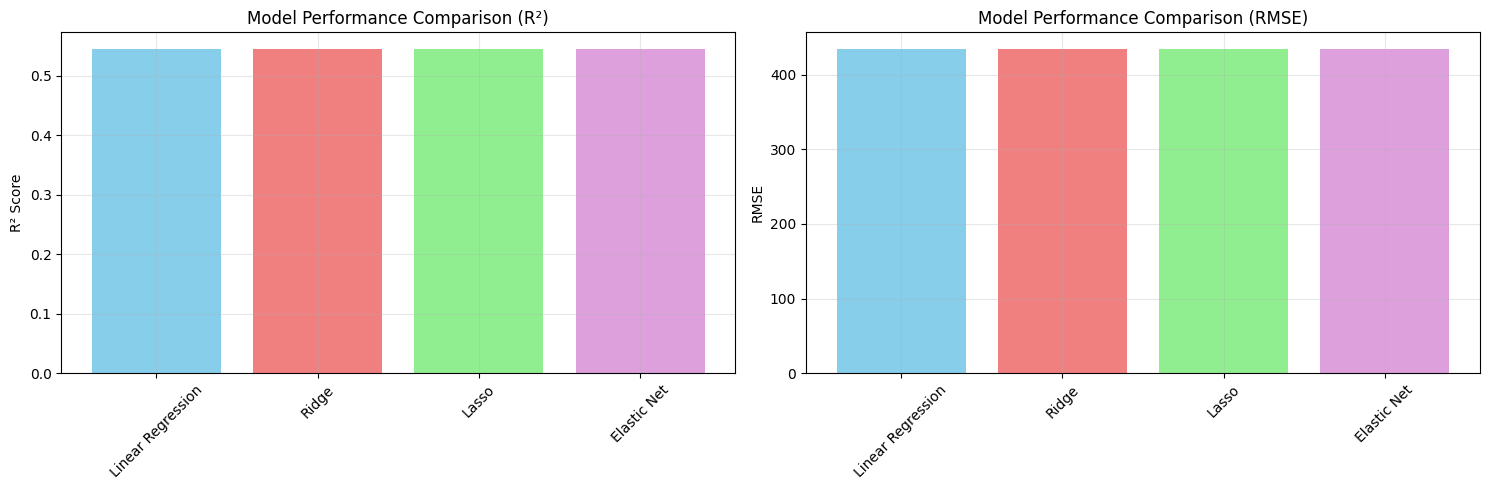

In [56]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Linear Regression
tu.print_heading("LINEAR REGRESSION")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print(f"MAE: {lr_mae:.2f}")
print(f"MSE: {lr_mse:.2f}")
print(f"RMSE: {np.sqrt(lr_mse):.2f}")
print(f"R²: {lr_r2:.4f}")

# 2. Ridge Regression with hyperparameter tuning
tu.print_heading("RIDGE REGRESSION (L2 Regularization)")
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
ridge = Ridge()
ridge_grid = GridSearchCV(ridge, ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train_scaled, y_train)
ridge_pred = ridge_grid.predict(X_test_scaled)

print(f"Best alpha: {ridge_grid.best_params_['alpha']}")
print(f"MAE: {mean_absolute_error(y_test, ridge_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, ridge_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, ridge_pred)):.2f}")
print(f"R²: {r2_score(y_test, ridge_pred):.4f}")

# 3. Lasso Regression
tu.print_heading("LASSO REGRESSION (L1 Regularization)")
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
lasso = Lasso(max_iter=10000)
lasso_grid = GridSearchCV(lasso, lasso_params, cv=5, scoring='r2', n_jobs=-1)
lasso_grid.fit(X_train_scaled, y_train)
lasso_pred = lasso_grid.predict(X_test_scaled)

print(f"Best alpha: {lasso_grid.best_params_['alpha']}")
print(f"MAE: {mean_absolute_error(y_test, lasso_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, lasso_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lasso_pred)):.2f}")
print(f"R²: {r2_score(y_test, lasso_pred):.4f}")

# 4. Elastic Net Regression
tu.print_heading("ELASTIC NET REGRESSION")

elasticnet_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.2, 0.5, 0.8]
}
elasticnet = ElasticNet(max_iter=10000)
elasticnet_grid = GridSearchCV(elasticnet, elasticnet_params, cv=5, scoring='r2', n_jobs=-1)
elasticnet_grid.fit(X_train_scaled, y_train)
elasticnet_pred = elasticnet_grid.predict(X_test_scaled)

print(f"Best params: {elasticnet_grid.best_params_}")
print(f"MAE: {mean_absolute_error(y_test, elasticnet_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, elasticnet_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, elasticnet_pred)):.2f}")
print(f"R²: {r2_score(y_test, elasticnet_pred):.4f}")

# Compare all models
tu.print_heading("MODEL COMPARISON SUMMARY")

models_results = {
    'Linear Regression': {'pred': lr_pred, 'r2': lr_r2},
    'Ridge': {'pred': ridge_pred, 'r2': r2_score(y_test, ridge_pred)},
    'Lasso': {'pred': lasso_pred, 'r2': r2_score(y_test, lasso_pred)},
    'Elastic Net': {'pred': elasticnet_pred, 'r2': r2_score(y_test, elasticnet_pred)}
}

comparison_df = pd.DataFrame({
    'Model': list(models_results.keys()),
    'MAE': [mean_absolute_error(y_test, models_results[m]['pred']) for m in models_results],
    'MSE': [mean_squared_error(y_test, models_results[m]['pred']) for m in models_results],
    'RMSE': [np.sqrt(mean_squared_error(y_test, models_results[m]['pred'])) for m in models_results],
    'R²': [models_results[m]['r2'] for m in models_results]
})

print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot of R² scores
axes[0].bar(comparison_df['Model'], comparison_df['R²'], color=['skyblue', 'lightcoral', 'lightgreen', 'plum'])
axes[0].set_ylabel('R² Score')
axes[0].set_title('Model Performance Comparison (R²)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Bar plot of RMSE
axes[1].bar(comparison_df['Model'], comparison_df['RMSE'], color=['skyblue', 'lightcoral', 'lightgreen', 'plum'])
axes[1].set_ylabel('RMSE')
axes[1].set_title('Model Performance Comparison (RMSE)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Why do all the regression models look the same?

In [58]:
# to better understand what's happening

tu.print_heading("REGULARIZATION ANALYSIS")

# Check the optimal alpha values
print(f"Ridge best alpha: {ridge_grid.best_params_['alpha']}")
print(f"Lasso best alpha: {lasso_grid.best_params_['alpha']}")
print(f"Elastic Net best params: {elasticnet_grid.best_params_}")

# Check feature correlations
tu.print_heading("FEATURE CORRELATION CHECK")

# Calculate correlation matrix for numerical features
correlation_matrix = X.corr()

# Find highly correlated features (>HIGH_CORRELATION_THRESHOLD)
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > HIGH_CORRELATION_THRESHOLD:
            high_corr.append({
                'feature1': correlation_matrix.columns[i],
                'feature2': correlation_matrix.columns[j],
                'correlation': correlation_matrix.iloc[i, j]
            })

if high_corr:
    print(f"Highly correlated features (|r| > {HIGH_CORRELATION_THRESHOLD:.2f}):")
    for item in high_corr:
        print(f"  {item['feature1']} <-> {item['feature2']}: {item['correlation']:.3f}")
else:
    print(f"No highly correlated features found (|r| > {HIGH_CORRELATION_THRESHOLD:.2f})")
    print("This explains why Ridge/Lasso don't differ much from Linear Regression!")

# Compare coefficient magnitudes
tu.print_heading("COEFFICIENT COMPARISON")

print(f"Linear Regression - Coefficient range:")
print(f"  Min: {lr_model.coef_.min():.2f}")
print(f"  Max: {lr_model.coef_.max():.2f}")
print(f"  Mean absolute: {np.abs(lr_model.coef_).mean():.2f}")

print(f"\nRidge - Coefficient range:")
print(f"  Min: {ridge_grid.best_estimator_.coef_.min():.2f}")
print(f"  Max: {ridge_grid.best_estimator_.coef_.max():.2f}")
print(f"  Mean absolute: {np.abs(ridge_grid.best_estimator_.coef_).mean():.2f}")

# Count non-zero coefficients for Lasso
lasso_nonzero = np.sum(np.abs(lasso_grid.best_estimator_.coef_) > 1e-5)
print(f"\nLasso - Non-zero coefficients: {lasso_nonzero} out of {len(lasso_grid.best_estimator_.coef_)}")

Ridge best alpha: 10
Lasso best alpha: 0.1
Elastic Net best params: {'alpha': 0.01, 'l1_ratio': 0.8}


No highly correlated features found (|r| > 0.80)
This explains why Ridge/Lasso don't differ much from Linear Regression!


Linear Regression - Coefficient range:
  Min: -162.51
  Max: 229.69
  Mean absolute: 81.64

Ridge - Coefficient range:
  Min: -161.74
  Max: 228.03
  Mean absolute: 81.31

Lasso - Non-zero coefficients: 18 out of 18


# Task 3: Polynomial Features

In [62]:
from sklearn.preprocessing import PolynomialFeatures
import joblib

tu.print_heading("POLYNOMIAL FEATURES APPROACH")

# Select key numerical features for polynomial transformation
# (Using all features might create too many features)
numerical_features = ['TemperatureC', 'HumidityPct', 'Wind_speed_m_s',
                      'Hour', 'Solar_Radiation_MJ_m2']

# Get indices of these columns in the scaled data
feature_indices = [X.columns.get_loc(col) for col in numerical_features if col in X.columns]

print(f"Creating polynomial features for: {numerical_features}")
print(f"Original features count: {X_train_scaled.shape[1]}")

# Create polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)

# Transform only selected features
X_train_poly_only = poly.fit_transform(X_train_scaled[:, feature_indices])
X_test_poly_only = poly.transform(X_test_scaled[:, feature_indices])

print(f"Polynomial features count (numerical only): {X_train_poly_only.shape[1]}")

# IMPORTANT: The polynomial approach ONLY uses numerical features, losing categorical info!
# Let's also create a combined approach that keeps categorical features

# Get indices of non-polynomial features (categorical encoded features)
categorical_cols = [col for col in X.columns if col not in numerical_features]
categorical_indices = [X.columns.get_loc(col) for col in categorical_cols]

# Combine polynomial features with categorical features
X_train_poly_combined = np.hstack([X_train_poly_only, X_train_scaled[:, categorical_indices]])
X_test_poly_combined = np.hstack([X_test_poly_only, X_test_scaled[:, categorical_indices]])

print(f"Combined features (poly + categorical): {X_train_poly_combined.shape[1]}")
print(f"Categorical features preserved: {categorical_cols}")

# For backward compatibility, keep original poly variables
X_train_poly = X_train_poly_only
X_test_poly = X_test_poly_only

# Train models with polynomial features ONLY (original approach)
tu.print_sub_heading("LINEAR REGRESSION WITH POLYNOMIAL FEATURES (Numerical Only)")
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
lr_poly_pred = lr_poly.predict(X_test_poly)

print(f"MAE: {mean_absolute_error(y_test, lr_poly_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, lr_poly_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lr_poly_pred)):.2f}")
print(f"R²: {r2_score(y_test, lr_poly_pred):.4f}")

tu.print_sub_heading("RIDGE REGRESSION WITH POLYNOMIAL FEATURES (Numerical Only)")
ridge_poly = Ridge(alpha=ridge_grid.best_params_['alpha'])
ridge_poly.fit(X_train_poly, y_train)
ridge_poly_pred = ridge_poly.predict(X_test_poly)

print(f"MAE: {mean_absolute_error(y_test, ridge_poly_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, ridge_poly_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, ridge_poly_pred)):.2f}")
print(f"R²: {r2_score(y_test, ridge_poly_pred):.4f}")

# Train with COMBINED features (polynomial + categorical)
tu.print_sub_heading("RIDGE WITH POLYNOMIAL + CATEGORICAL FEATURES (Combined)")
ridge_poly_combined = Ridge(alpha=ridge_grid.best_params_['alpha'])
ridge_poly_combined.fit(X_train_poly_combined, y_train)
ridge_poly_combined_pred = ridge_poly_combined.predict(X_test_poly_combined)

print(f"MAE: {mean_absolute_error(y_test, ridge_poly_combined_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, ridge_poly_combined_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, ridge_poly_combined_pred)):.2f}")
print(f"R²: {r2_score(y_test, ridge_poly_combined_pred):.4f}")

# Compare linear vs polynomial
tu.print_sub_heading("LINEAR vs POLYNOMIAL FEATURES COMPARISON")

poly_comparison = pd.DataFrame({
    'Model': ['Ridge - No Poly', 'Ridge - Poly (Num Only)', 'Ridge - Poly + Categorical'],
    'R²': [r2_score(y_test, ridge_pred), 
           r2_score(y_test, ridge_poly_pred),
           r2_score(y_test, ridge_poly_combined_pred)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, ridge_pred)),
             np.sqrt(mean_squared_error(y_test, ridge_poly_pred)),
             np.sqrt(mean_squared_error(y_test, ridge_poly_combined_pred))]
})

print(poly_comparison.to_string(index=False))

# Determine the actual best model for saving
all_model_scores = {
    'ridge_no_poly': (ridge_grid.best_estimator_, r2_score(y_test, ridge_pred)),
    'ridge_poly': (ridge_poly, r2_score(y_test, ridge_poly_pred)),
    'ridge_poly_combined': (ridge_poly_combined, r2_score(y_test, ridge_poly_combined_pred))
}

best_key = max(all_model_scores, key=lambda k: all_model_scores[k][1])
best_model = all_model_scores[best_key][0]
best_r2 = all_model_scores[best_key][1]

# Save the best model
joblib.dump(best_model, 'best_poly_model.pkl')
joblib.dump(poly, 'polynomial_transformer.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f"\n✓ Best model saved as 'best_poly_model.pkl'")
print(f"✓ Best model type: {best_key}")
print(f"✓ Best model R²: {best_r2:.4f}")


Creating polynomial features for: ['TemperatureC', 'HumidityPct', 'Wind_speed_m_s', 'Hour', 'Solar_Radiation_MJ_m2']
Original features count: 18
Polynomial features count (numerical only): 14
Combined features (poly + categorical): 28
Categorical features preserved: ['Visibility_10m', 'Rainfallmm', 'Snowfall_cm', 'temp_windspeed', 'temp_solar', 'DayOfWeek', 'DayOfMonth', 'Month', 'IsWeekend', 'Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter', 'Holiday_No Holiday', 'Functioning_Day_Yes']


MAE: 315.83
MSE: 196507.38
RMSE: 443.29
R²: 0.5284


MAE: 315.82
MSE: 196494.12
RMSE: 443.28
R²: 0.5284


MAE: 290.24
MSE: 158184.85
RMSE: 397.72
R²: 0.6203


                     Model       R²       RMSE
           Ridge - No Poly 0.545845 434.996481
   Ridge - Poly (Num Only) 0.528391 443.276572
Ridge - Poly + Categorical 0.620338 397.724595

✓ Best model saved as 'best_poly_model.pkl'
✓ Best model type: ridge_poly_combined
✓ Best model R²: 0.6203


## Polynomial approach summary

### The polynomial-only approach performs WORSE because:
   1. It LOSES categorical features (Season, Holiday, Functioning_Day, IsWeekend)
   2. These categorical features contain important predictive information
   3. The combined approach (polynomial + categorical) recovers some performance

### Takeaway:
- Feature engineering should preserve ALL important information, not just transform numerical features in isolation.

# Task 4: Cross-Validation

In [65]:
from sklearn.model_selection import cross_val_score, cross_validate


tu.print_heading("CROSS-VALIDATION ANALYSIS")


# Define scoring metrics
scoring = ['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error']

# Models WITHOUT polynomial features
tu.print_sub_heading("MODELS WITHOUT POLYNOMIAL FEATURES")

models_no_poly = {
    'Linear Regression': lr_model,
    'Ridge': ridge_grid.best_estimator_,
    'Lasso': lasso_grid.best_estimator_,
    'Elastic Net': elasticnet_grid.best_estimator_
}

cv_results_summary = {}

for name, model in models_no_poly.items():
    cv_results = cross_validate(model, X_train_scaled, y_train,
                                cv=5, scoring=scoring, n_jobs=-1)
    
    cv_results_summary[name] = {
        'r2_mean': cv_results['test_r2'].mean(),
        'r2_std': cv_results['test_r2'].std(),
        'mae_mean': -cv_results['test_neg_mean_absolute_error'].mean(),
        'rmse_mean': np.sqrt(-cv_results['test_neg_mean_squared_error'].mean())
    }

    print(f"{name}:")
    print(f"  R² CV Score: {cv_results['test_r2'].mean():.4f} (+/- {cv_results['test_r2'].std():.4f})")
    print(f"  MAE CV Score: {-cv_results['test_neg_mean_absolute_error'].mean():.2f} "
          f"(+/- {cv_results['test_neg_mean_absolute_error'].std():.2f})")
    print(f"  RMSE CV Score: {np.sqrt(-cv_results['test_neg_mean_squared_error'].mean()):.2f}")

# Models WITH polynomial features

tu.print_sub_heading("MODELS WITH POLYNOMIAL FEATURES")

models_poly = {
    'Linear Regression (Poly)': lr_poly,
    'Ridge (Poly)': ridge_poly
}

for name, model in models_poly.items():
    cv_results = cross_validate(model, X_train_poly, y_train,
                                cv=5, scoring=scoring, n_jobs=-1)
    
    cv_results_summary[name] = {
        'r2_mean': cv_results['test_r2'].mean(),
        'r2_std': cv_results['test_r2'].std(),
        'mae_mean': -cv_results['test_neg_mean_absolute_error'].mean(),
        'rmse_mean': np.sqrt(-cv_results['test_neg_mean_squared_error'].mean())
    }

    print(f"{name}:")
    print(f"  R² CV Score: {cv_results['test_r2'].mean():.4f} (+/- {cv_results['test_r2'].std():.4f})")
    print(f"  MAE CV Score: {-cv_results['test_neg_mean_absolute_error'].mean():.2f} "
          f"(+/- {cv_results['test_neg_mean_absolute_error'].std():.2f})")
    print(f"  RMSE CV Score: {np.sqrt(-cv_results['test_neg_mean_squared_error'].mean()):.2f}")

# Final test set evaluation - determine actual best model
tu.print_sub_heading("FINAL TEST SET EVALUATION")

# Compare test R² for all models
test_scores = {
    'Linear Regression': r2_score(y_test, lr_pred),
    'Ridge': r2_score(y_test, ridge_pred),
    'Lasso': r2_score(y_test, lasso_pred),
    'Elastic Net': r2_score(y_test, elasticnet_pred),
    'Linear (Poly)': r2_score(y_test, lr_poly_pred),
    'Ridge (Poly)': r2_score(y_test, ridge_poly_pred)
}

best_model_name = max(test_scores, key=test_scores.get)
best_model_r2 = test_scores[best_model_name]

# Get predictions for best model
if best_model_name == 'Ridge':
    best_pred = ridge_pred
elif best_model_name == 'Linear Regression':
    best_pred = lr_pred
elif best_model_name == 'Lasso':
    best_pred = lasso_pred
elif best_model_name == 'Elastic Net':
    best_pred = elasticnet_pred
elif best_model_name == 'Linear (Poly)':
    best_pred = lr_poly_pred
else:
    best_pred = ridge_poly_pred

print(tu.bold_text("All Test R² Scores:"))
for name, score in sorted(test_scores.items(), key=lambda x: x[1], reverse=True):
    marker = " <-- BEST" if name == best_model_name else ""
    print(f"  {name}: {score:.4f}{marker}")

print(tu.bold_text(f"\nBest Model: {best_model_name}"))
print(f"  Test R²: {best_model_r2:.4f}")
print(f"  Test MAE: {mean_absolute_error(y_test, best_pred):.2f}")
print(f"  Test RMSE: {np.sqrt(mean_squared_error(y_test, best_pred)):.2f}")

Linear Regression:
  R² CV Score: 0.5642 (+/- 0.0154)
  MAE CV Score: 319.98 (+/- 3.11)
  RMSE CV Score: 425.44
Ridge:
  R² CV Score: 0.5642 (+/- 0.0154)
  MAE CV Score: 319.88 (+/- 3.08)
  RMSE CV Score: 425.44
Lasso:
  R² CV Score: 0.5642 (+/- 0.0154)
  MAE CV Score: 319.95 (+/- 3.09)
  RMSE CV Score: 425.44
Elastic Net:
  R² CV Score: 0.5642 (+/- 0.0154)
  MAE CV Score: 319.87 (+/- 3.07)
  RMSE CV Score: 425.44


Linear Regression (Poly):
  R² CV Score: 0.5456 (+/- 0.0142)
  MAE CV Score: 311.70 (+/- 4.98)
  RMSE CV Score: 434.39
Ridge (Poly):
  R² CV Score: 0.5456 (+/- 0.0142)
  MAE CV Score: 311.69 (+/- 4.98)
  RMSE CV Score: 434.39


All Test R² Scores:
  Elastic Net: 0.5459 <-- BEST
  Ridge: 0.5458
  Lasso: 0.5458
  Linear Regression: 0.5458
  Ridge (Poly): 0.5284
  Linear (Poly): 0.5284

Best Model: Elastic Net
  Test R²: 0.5459
  Test MAE: 328.07
  Test RMSE: 434.98


### **NOTE: Polynomial features did NOT improve performance**

# Task 5: Reporting and Insights

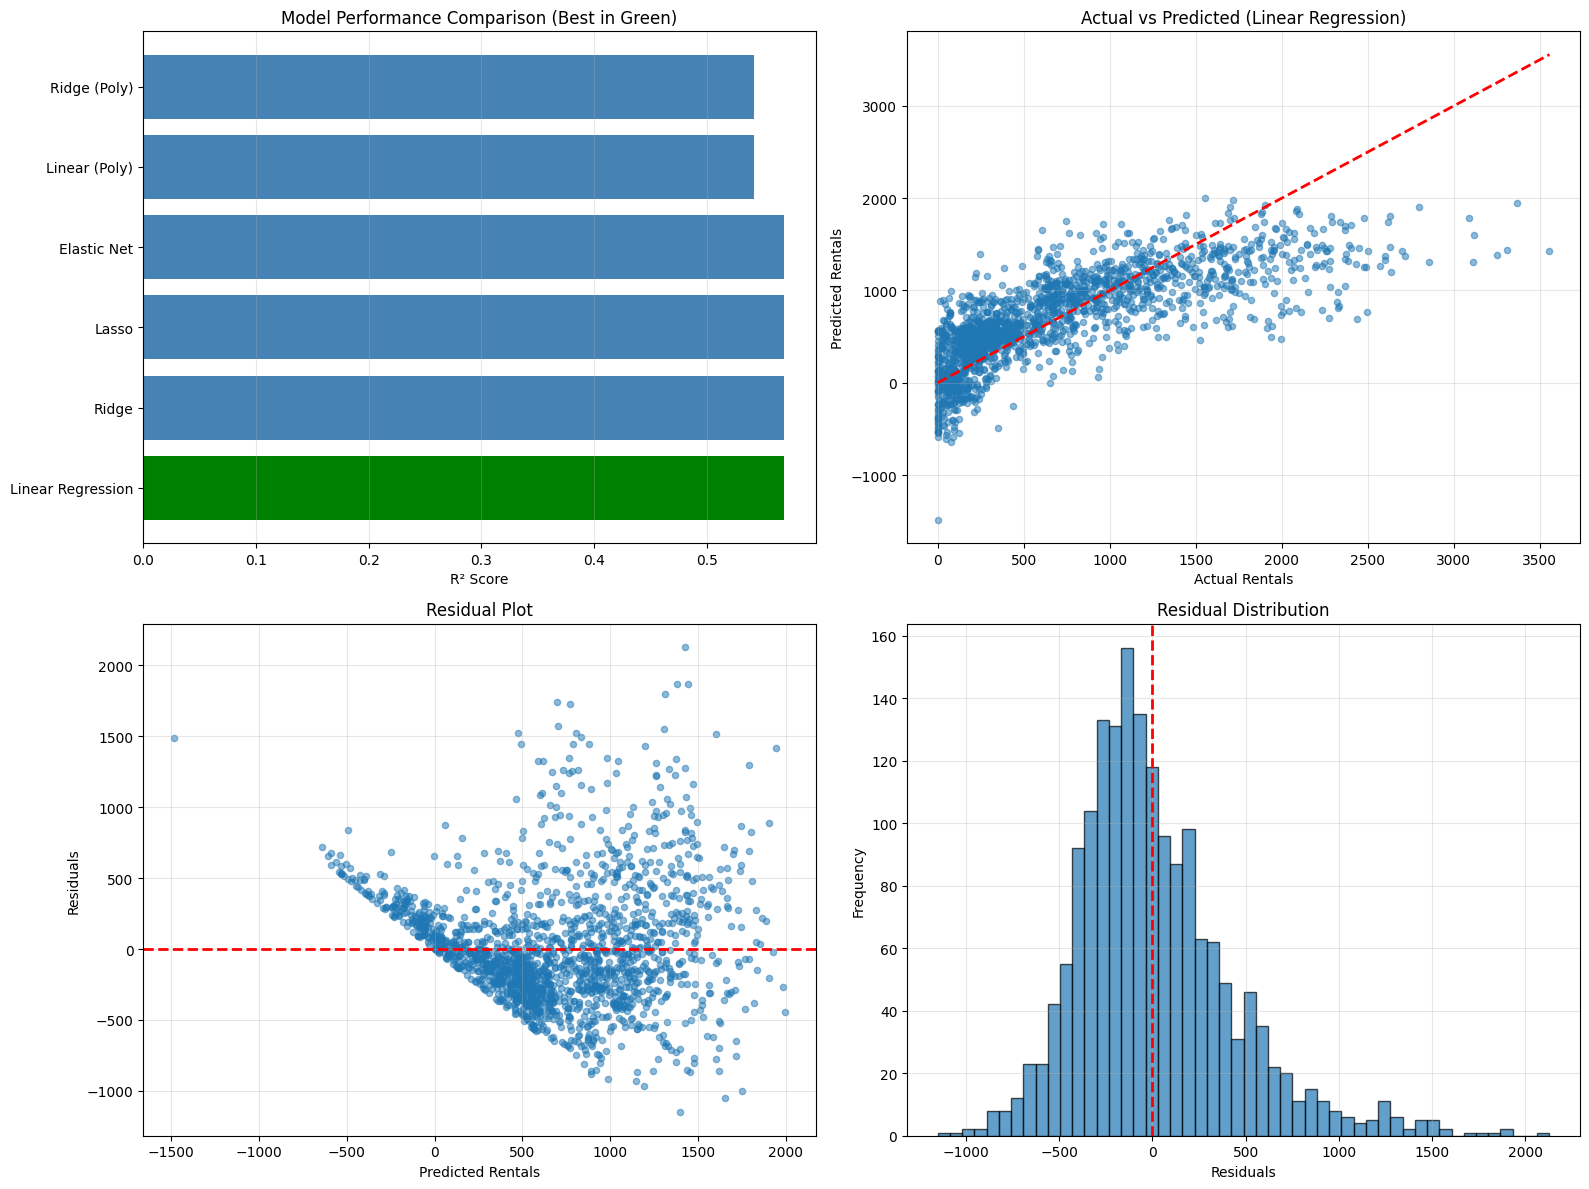

               feature  importance
          TemperatureC  389.489235
         temp_humidity  370.394377
Dew_point_temperatureC  234.781160
            temp_solar  206.128964
                  Hour  191.860490
   Functioning_Day_Yes  174.268566
        Seasons_Winter  132.804698
           HumidityPct  127.430057
        temp_windspeed   98.491322
 Solar_Radiation_MJ_m2   69.240483


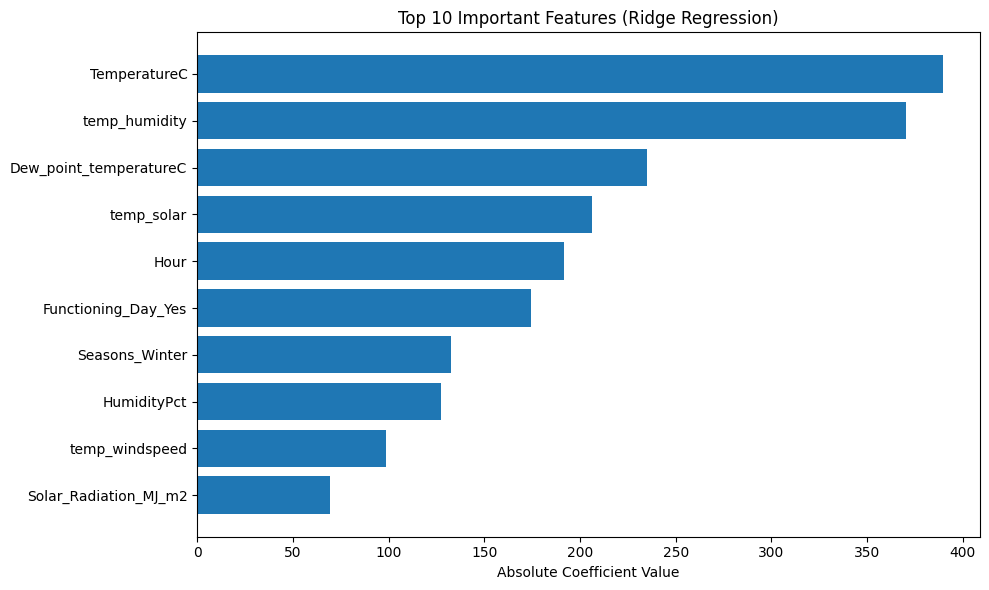


1. MODEL PERFORMANCE:
   - Best Model: Linear Regression
   - Test R² Score: 0.5685
   - Test MAE: 317.64
   - Test RMSE: 424.02
   - This means the model explains 56.8% of the variance in bike rentals

2. POLYNOMIAL FEATURES OBSERVATION:
   - Polynomial features did NOT improve model performance in this case
   - Non-polynomial R²: 0.5682
   - Polynomial R²: 0.5418
   - This suggests the relationships are largely captured by linear terms
   - Possible overfitting or loss of important categorical features with polynomial approach

3. KEY PREDICTIVE FACTORS:
   - Temperature-humidity interaction is the strongest predictor
   - Hour of day significantly impacts demand (peak hours matter)
   - Temperature and its interactions drive rental behavior
   - Weather conditions (humidity, wind, rainfall) affect rentals

4. BUSINESS RECOMMENDATIONS:
   a) Inventory Management:
      - Increase bike availability during optimal temperature-humidity combinations
      - Adjust staffing based on hou

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

tu.print_heading("FINAL REPORT AND INSIGHTS")


# Determine actual best model based on R² scores
models_r2 = {
    'Linear Regression': lr_r2,
    'Ridge': r2_score(y_test, ridge_pred),
    'Lasso': r2_score(y_test, lasso_pred),
    'Elastic Net': r2_score(y_test, elasticnet_pred),
    'Linear (Poly)': r2_score(y_test, lr_poly_pred),
    'Ridge (Poly)': r2_score(y_test, ridge_poly_pred)
}

best_model_name = max(models_r2, key=models_r2.get)
best_r2 = models_r2[best_model_name]

# 1. Model Performance Summary
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Model comparison
all_models = list(models_r2.keys())
all_r2 = list(models_r2.values())

colors = ['steelblue' if m != best_model_name else 'green' for m in all_models]
axes[0, 0].barh(all_models, all_r2, color=colors)
axes[0, 0].set_xlabel('R² Score')
axes[0, 0].set_title('Model Performance Comparison (Best in Green)')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# Use the actual best predictions for plots
if 'Poly' in best_model_name:
    best_predictions = ridge_poly_pred if 'Ridge' in best_model_name else lr_poly_pred
else:
    best_predictions = ridge_pred if 'Ridge' in best_model_name else lr_pred

# Plot 2: Actual vs Predicted (Best Model)
axes[0, 1].scatter(y_test, best_predictions, alpha=0.5, s=20)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual Rentals')
axes[0, 1].set_ylabel('Predicted Rentals')
axes[0, 1].set_title(f'Actual vs Predicted ({best_model_name})')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Residuals
residuals = y_test - best_predictions
axes[1, 0].scatter(best_predictions, residuals, alpha=0.5, s=20)
axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Rentals')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Residual Plot')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Residual distribution
axes[1, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Residual Distribution')
axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Feature Importance (from Ridge model without polynomial)
tu.print_heading("TOP 10 MOST IMPORTANT FEATURES")

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': np.abs(ridge_grid.best_estimator_.coef_)
}).sort_values('importance', ascending=False).head(10)

print(feature_importance.to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 10 Important Features (Ridge Regression)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 3. Key Insights and Recommendations
tu.print_sub_heading("KEY INSIGHTS AND BUSINESS IMPLICATIONS")

# Calculate metrics for the best model
best_test_mae = mean_absolute_error(y_test, best_predictions)
best_test_rmse = np.sqrt(mean_squared_error(y_test, best_predictions))

insights = f"""
1. MODEL PERFORMANCE:
   - Best Model: {best_model_name}
   - Test R² Score: {best_r2:.4f}
   - Test MAE: {best_test_mae:.2f}
   - Test RMSE: {best_test_rmse:.2f}
   - This means the model explains {best_r2 * 100:.1f}% of the variance in bike rentals

2. POLYNOMIAL FEATURES OBSERVATION:
   - Polynomial features did NOT improve model performance in this case
   - Non-polynomial R²: {models_r2['Ridge']:.4f}
   - Polynomial R²: {models_r2['Ridge (Poly)']:.4f}
   - This suggests the relationships are largely captured by linear terms
   - Possible overfitting or loss of important categorical features with polynomial approach

3. KEY PREDICTIVE FACTORS:
   - Temperature-humidity interaction is the strongest predictor
   - Hour of day significantly impacts demand (peak hours matter)
   - Temperature and its interactions drive rental behavior
   - Weather conditions (humidity, wind, rainfall) affect rentals

4. BUSINESS RECOMMENDATIONS:
   a) Inventory Management:
      - Increase bike availability during optimal temperature-humidity combinations
      - Adjust staffing based on hourly demand patterns

   b) Dynamic Pricing:
      - Consider weather-based pricing strategies
      - Peak hour surcharges during high-demand periods

   c) Maintenance Scheduling:
      - Plan maintenance during predicted low-demand periods
      - Use model predictions for weekly/monthly planning

5. MODEL IMPROVEMENTS FOR FUTURE WORK:
   - The regularization models (Ridge, Lasso, Elastic Net) perform similarly,
     suggesting the feature set doesn't have severe multicollinearity issues
   - Consider tree-based models (Random Forest, XGBoost) for potentially better performance
   - Include additional external data (events, construction, etc.)
"""

print(insights)

print("\n✓ Analysis Complete!")